# Solar energy - Predictions for one MONTH & one STATION

import de toutes les librairies nécessaires

In [1]:
# pour la manipulation de données
import numpy as np
import pandas as pd

# pour tracer les graphes
import seaborn as sns
import matplotlib.pyplot as plt

# options d'affichage
pd.options.display.max_columns = 300

import warnings
warnings.filterwarnings("ignore")

## Data preparation

chargement du fichier csv dans un dataframe

In [4]:
df = pd.read_csv("solar_generation_by_station.csv")

fonction qui ajoute les dates avec l'année, le mois, le numéro de la semaine et du jour dans l'année, l'heure de la journée

In [5]:
def add_date_time(_df):
    "Returns a DF with two new cols : the time and hour of the day"
    t = pd.date_range(start='1/1/1986', periods=_df.shape[0], freq = 'H')
    t = pd.DataFrame(t)
    _df = pd.concat([_df, t], axis=1)
    _df.rename(columns={ _df.columns[-1]: "time" }, inplace = True)
    _df['year'] = _df['time'].dt.year
    _df['month'] = _df['time'].dt.month
    _df['week'] = _df['time'].dt.weekofyear
    _df['day'] = _df['time'].dt.dayofyear    
    _df['hour'] = _df['time'].dt.hour
    return _df

on ne conserve que quelques années et les colonnes qui nous interesse.

In [6]:
df = add_date_time(df)
df = df[~df.year.isin([1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016])]

# keeping only values for one country for the predictions
df = df[['FR10', 'year', 'month', 'week', 'day', 'hour', 'time']]
df.head(2)

,FR10,year,month,week,day,hour,time
0,0.0,1986,1,1,1,0,1986-01-01 00:00:00
1,0.0,1986,1,1,1,1,1986-01-01 01:00:00


nombre de ligne du dataframe et de colonnes

In [7]:
df.shape

(201480, 7)

séparation du jeux données en 
- une partie pour le train : sert à l'entrainement du modèle, le modèle connait les valeurs de rendement sur ce jeu de donnée
- une partie pour le test : le modèle n'a jamais vu ce jeu de données et ne connait pas les valeurs de rendements.

In [8]:
# train data for 10 years
train_data = df[-24*365*10:-24*31]

# test data = last month of records / 2015
test_data = df[-24*31:]

# Model Training

## metrique

Comme vu précédmeent dans l'analyse exploratoire, le jeux de données est propre : il n'y a pas de valeur abérrante, pas de ligne dupliquée, par de valeurs manquantes. Nous allons utiliser la root mean square error comme métrique pour évaluer la performance des modèles.

Nous allons tester plusieurs type de regression pour faire des prédictions de rendement de l'installation photovoltaique. Pour trouver quel est le modèle le plus performant nous allons comparer les erreurs sur la partie test du jeux de donnée

In [9]:
from sklearn.metrics import mean_squared_error
model_instances, model_names, rmse_train, rmse_test = [], [], [], []

# cette fonction ne sert qu'a afficher les diagrammes à barre des erreurs des différents modèles

def plot_scores():
    df_score = pd.DataFrame({'model_names' : model_names,
                             'rmse_train' : rmse_train,
                             'rmse_test' : rmse_test})
    df_score = pd.melt(df_score, id_vars=['model_names'], value_vars=['rmse_train', 'rmse_test'])

    plt.figure(figsize=(12, 10))
    sns.barplot(y="model_names", x="value", hue="variable", data=df_score)
    plt.show()

## baseline

modèle de base pour le comparer aux autres, il s'agit d'un prédicateur relativement simple qui prend la moyenne des années passées : par exemple pour le jour 358 de l'année à l'heure entre 12 et 13h, ce modèle retourne la valeur moyenne des 10 années passées...

In [10]:
x_train, y_train = train_data.drop(columns=['time']), train_data['FR10']
x_test, y_test = test_data.drop(columns=['time']), test_data['FR10']

In [11]:
def mean_df(d, h):
    "return the hourly mean of a specific day of the year"
    res = x_train[(x_train['day'] == d) & (x_train['hour'] == h)]['FR10'].mean()
    return res

    # examples 
    #df['col_3'] = df.apply(lambda x: f(x.col_1, x.col_2), axis=1)
    # x_train[(x_train['day'] == x['day']) & (x_train['hour'] == x['hour'])]['FR10'].mean()

In [12]:
#x_train['pred'] = x_train.apply(lambda x: mean_df(x.day, x.hour), axis=1)
x_test['pred'] = x_test.apply(lambda x: mean_df(x.day, x.hour), axis=1)

affichage du jeux de donnée de test avec la prediction : colonne "pred"

In [13]:
x_test.head()

,FR10,year,month,week,day,hour,pred
262224,0.0,2015,12,49,335,0,0.0
262225,0.0,2015,12,49,335,1,0.0
262226,0.0,2015,12,49,335,2,0.0
262227,0.0,2015,12,49,335,3,0.0
262228,0.0,2015,12,49,335,4,0.0


ajout des erreurs dans des listes qui serviront pour l'affichage du diagramme à barre

In [14]:
model_names.append("base_line")
rmse_train.append(np.sqrt(mean_squared_error(x_train['FR10'], x_train['FR10']))) # a modifier en pred
rmse_test.append(np.sqrt(mean_squared_error(x_test['FR10'], x_test['pred'])))

affichage des prédictions pour le dernier mois (en orange) et des valeurs réelles (en bleu)

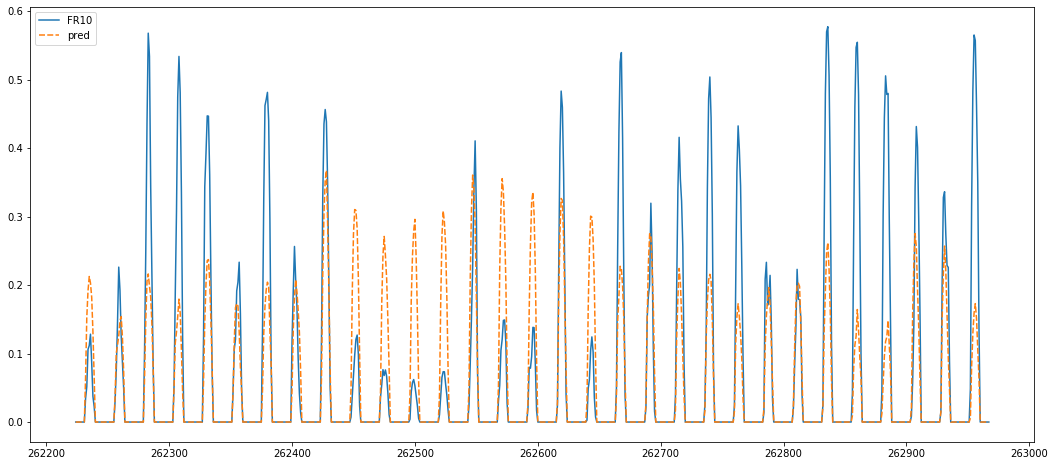

In [15]:
plt.figure(figsize=(18, 8))
sns.lineplot(data=x_test[['FR10', 'pred']])

## basic regression models

ici nous allons utiliser plusieurs modèles de régresssion linéaires

In [16]:
X_train, y_train = train_data[['month', 'week', 'day', 'hour']], train_data['FR10']
X_test, y_test = test_data[['month', 'week', 'day', 'hour']], test_data['FR10']
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((86856, 4), (86856,), (744, 4), (744,))

In [17]:
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

import xgboost as xgb
import lightgbm as lgbm

In [18]:
def get_rmse(reg, model_name):
    """Print the score for the model passed in argument and retrun scores for the train/test sets"""
    
    y_train_pred, y_pred = reg.predict(X_train), reg.predict(X_test)
    rmse_train, rmse_test = np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_pred))
    print(model_name, f'\t - RMSE on Training  = {rmse_train:.2f} / RMSE on Test = {rmse_test:.2f}')
    
    return rmse_train, rmse_test

In [19]:
# list of all the basic models used at first
model_list = [
    LinearRegression(), Lasso(), Ridge(), ElasticNet(),
    RandomForestRegressor(), GradientBoostingRegressor(), ExtraTreesRegressor(),
    xgb.XGBRegressor(), lgbm.LGBMRegressor()
             ]

# creation of list of names and scores for the train / test
model_names.extend([str(m)[:str(m).index('(')] for m in model_list])


# fit and predict all models
for model, name in zip(model_list, model_names):
    model.fit(X_train, y_train)
    sc_train, sc_test = get_rmse(model, name)
    rmse_train.append(sc_train)
    rmse_test.append(sc_test)

base_line 	 - RMSE on Training  = 0.21 / RMSE on Test = 0.15
LinearRegression 	 - RMSE on Training  = 0.21 / RMSE on Test = 0.15
Lasso 	 - RMSE on Training  = 0.21 / RMSE on Test = 0.15
Ridge 	 - RMSE on Training  = 0.21 / RMSE on Test = 0.15
ElasticNet 	 - RMSE on Training  = 0.10 / RMSE on Test = 0.10
RandomForestRegressor 	 - RMSE on Training  = 0.11 / RMSE on Test = 0.09
GradientBoostingRegressor 	 - RMSE on Training  = 0.10 / RMSE on Test = 0.10
[12:34:26] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost_1572314959925/work/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
ExtraTreesRegressor 	 - RMSE on Training  = 0.11 / RMSE on Test = 0.09
XGBRegressor 	 - RMSE on Training  = 0.10 / RMSE on Test = 0.10


In [20]:
gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)
y_pred = pd.DataFrame(gbr.predict(X_test))

In [21]:
y_test = pd.DataFrame(y_test)
y_test['pred'] = y_pred.values
y_test.head()

,FR10,pred
262224,0.0,-0.013495
262225,0.0,-0.013495
262226,0.0,-0.013495
262227,0.0,-0.013495
262228,0.0,-0.013495


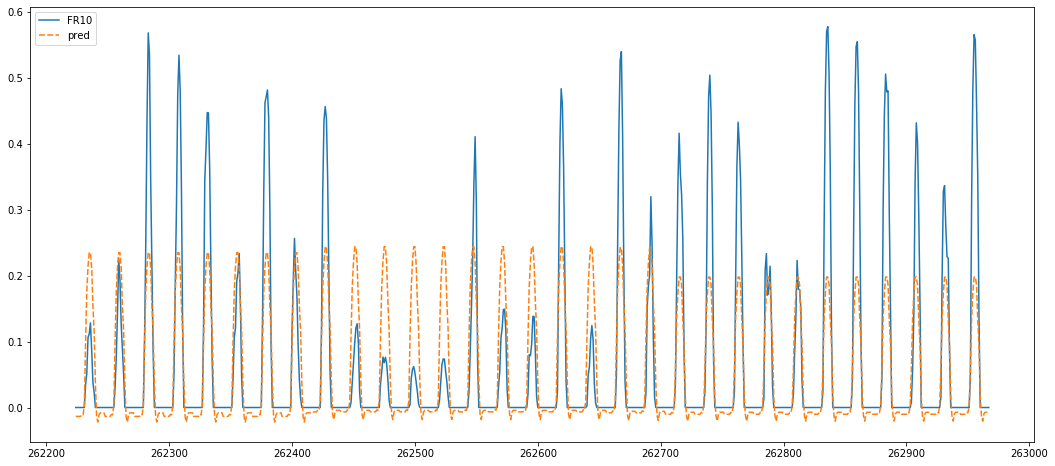

In [22]:
plt.figure(figsize=(18, 8))
sns.lineplot(data=y_test)

## with prophet a facebook lib for time series

Prophet est une librairie python de machine learning crée récemment par facebook.

Prophet suit le modèle d'API de scikit learn. nous créons une instance de classe Prophet et nous appelons ses méthodes "fit" et "predict".

L'entrée pour Prophet est toujours un dataframe avec 2 colonnes: ds et y. la colonne ds (datestamp) doit être de la forme  YYYY-MM-DD HH:MM:SS. la colonne y doit être numérique, et représente la mesure à prédire.

In [24]:
# on recharge les données comme avant
df = pd.read_csv("solar_generation_by_station.csv")
df = add_date_time(df)
#df = df[~df.year.isin([1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016])]

In [25]:
# on ne conserve que ce qui nous interesse
data = df[['time', 'FR10']]
data = data.rename(columns={"time": "ds", "FR10": "y"})

# pour la partie train on prend les 10 dernières années
train_data = data[-24*365*10:-24*31]

# pour la partie test que le dernier mois de 2015
test_data = data[-24*31:]

utilisons prophet sur les dernières données préparées

In [26]:
from fbprophet import Prophet

prophet_model = Prophet()

ERROR:fbprophet:Importing plotly failed. Interactive plots will not work.


In [27]:
prophet_model.fit(train_data)

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [28]:
test_data.tail()

,ds,y
262963,2015-12-31 19:00:00,0.0
262964,2015-12-31 20:00:00,0.0
262965,2015-12-31 21:00:00,0.0
262966,2015-12-31 22:00:00,0.0
262967,2015-12-31 23:00:00,0.0


In [29]:
#y_train_pred = prophet_model.predict(train_data)

In [30]:
forecast = prophet_model.predict(test_data)
forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast['FR10'] = test_data['y'].values
forecast.tail()

,ds,yhat,yhat_lower,yhat_upper,FR10
739,2015-12-31 19:00:00,-0.082307,-0.239531,0.081463,0.0
740,2015-12-31 20:00:00,-0.077637,-0.221813,0.083512,0.0
741,2015-12-31 21:00:00,-0.071139,-0.224903,0.079687,0.0
742,2015-12-31 22:00:00,-0.073426,-0.219529,0.089771,0.0
743,2015-12-31 23:00:00,-0.080386,-0.235072,0.077065,0.0


- "prophet" : correspond à la prédiction
- "prophet_lower" : correspond à une prédiction de la borne inférieure
- "prophet_upper" : même chose mais pour la borne supérieure

In [31]:
model_names.extend(["prophet", "prophet_lower", "prophet_upper"])

rmse_train.extend([0, 0, 0])

rmse_test.append(np.sqrt(mean_squared_error(test_data['y'], forecast['yhat'])))
rmse_test.append(np.sqrt(mean_squared_error(test_data['y'], forecast['yhat_lower'])))
rmse_test.append(np.sqrt(mean_squared_error(test_data['y'], forecast['yhat_upper'])))

affichage de la prédiction et des valeurs réelles de rendement de l'installation photovoltaique

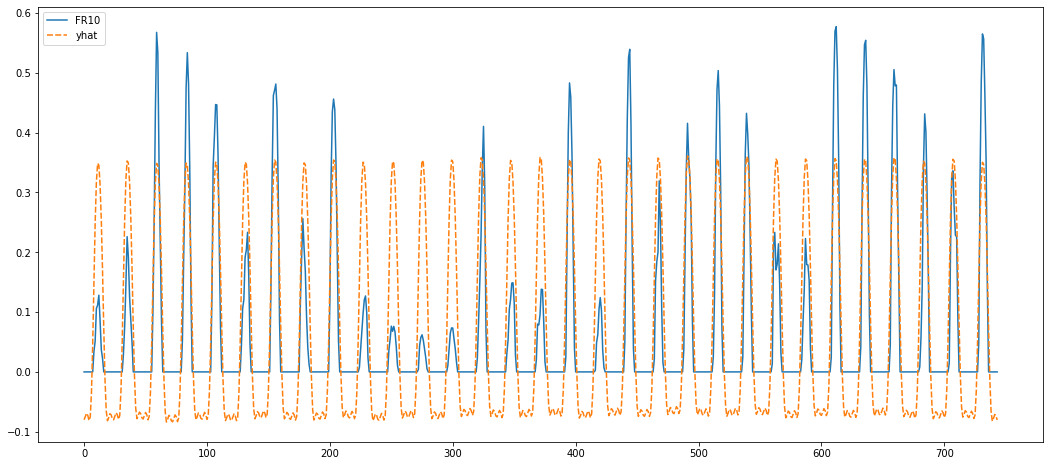

In [32]:
plt.figure(figsize=(18, 8))
sns.lineplot(data=forecast[['FR10', 'yhat']])

affichage des bornes inf et sup ainsi que des valeurs réelles de rendement de l'installation photovoltaique

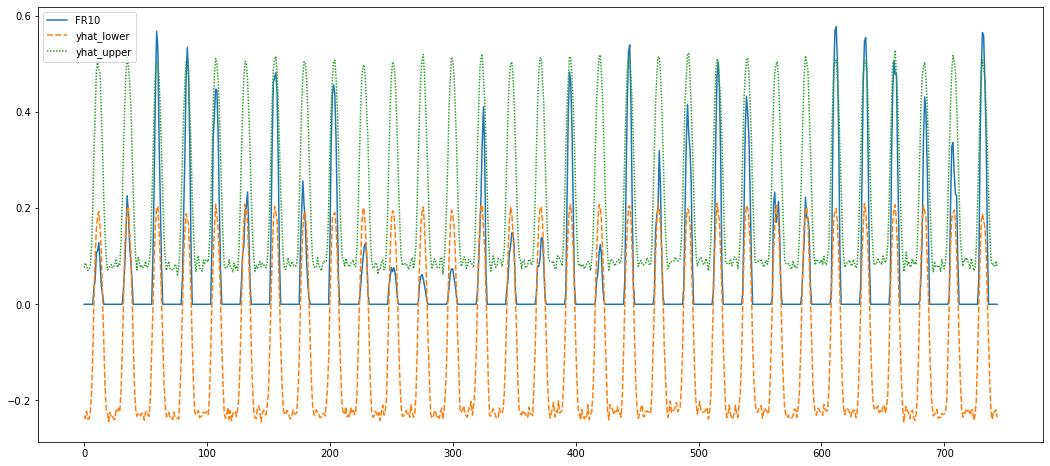

In [33]:
plt.figure(figsize=(18, 8))
sns.lineplot(data=forecast[['FR10', 'yhat_lower', 'yhat_upper']])

# Conclusion si l'on conserve le train / test

In [34]:
len(model_names), len(rmse_train), len(rmse_test)

(13, 13, 13)

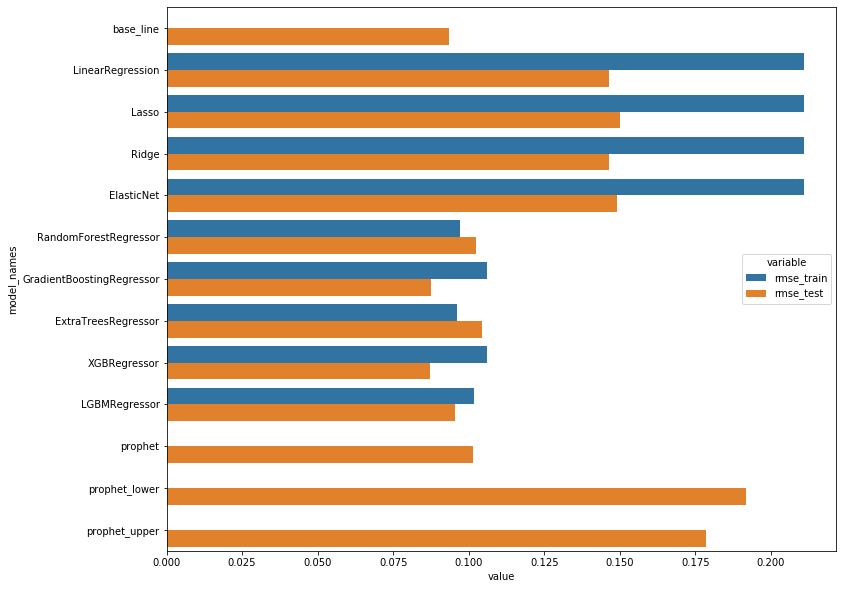

In [35]:
plot_scores()

- LGBM regressor par exemple présente une erreur de 0.1 environ sur la partie test. cette erreur est à relativiser par rapport aux valeurs de rendements qui vont de 0 à 1 en théorie (dans la pratique elle dépasse rarement 0.7)

- Finalememnt peu de modèles sont meilleurs que la baseline, mais sans différence vraiment notoire.
- la bibliothèque de Facebook n'est pas si performante pour ce genre de prédiction.

---

# Conclusion simplifiée pour la soutenance

on enlève les deux dernières valeurs qui correspondent aux bornes inf et sup de prophet qui n'apportent rien de plus.

In [41]:
model_names = model_names[:-2]
rmse_test = rmse_test[:-2]
rmse_train = rmse_train[:-2]

pour simplifier on ne considère pas la partie train, on ne regarde que l'erreur sur le test. Car le jeux de données test sert à évaluer le modèle sur des données qu'il ne connait pas

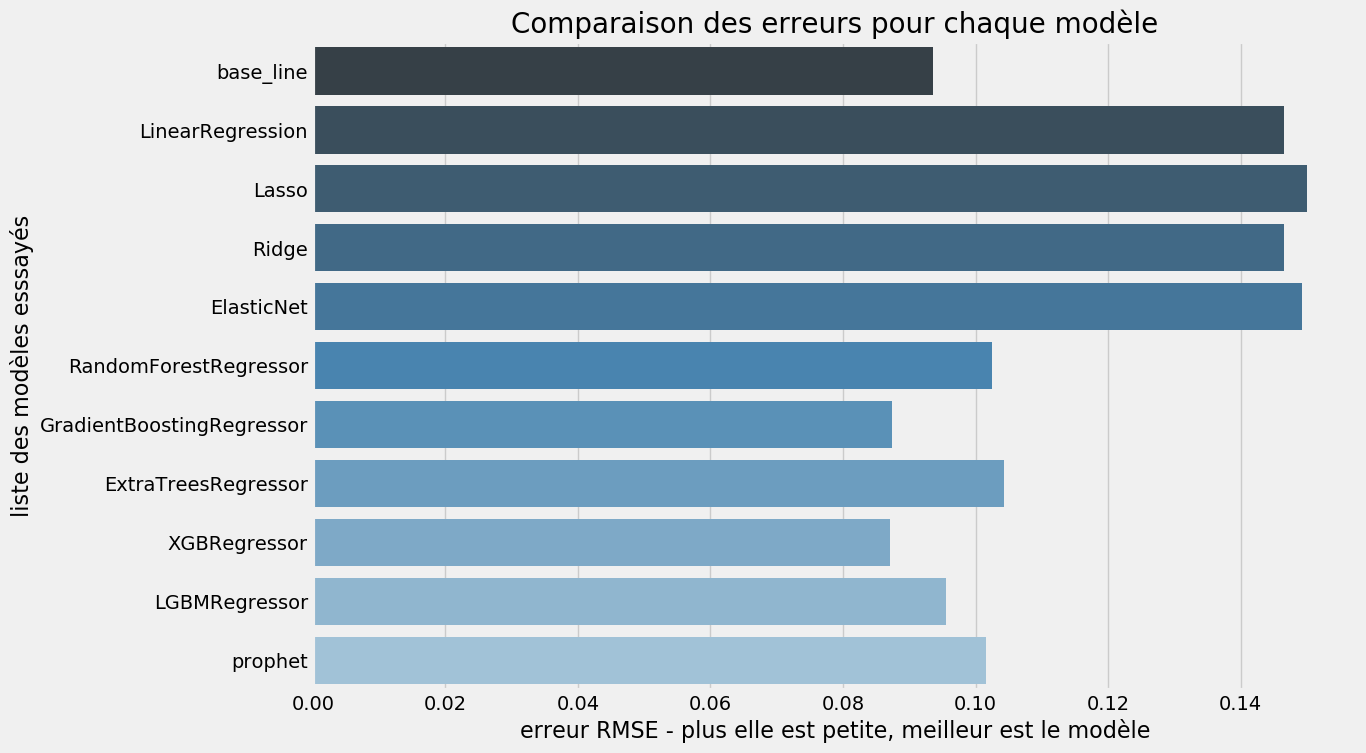

In [76]:
df_score = pd.DataFrame({'model_names' : model_names, 'rmse_test' : rmse_test})

plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 8))
sns.barplot(y="model_names", x="rmse_test", data=df_score, palette="Blues_d")
plt.title("Comparaison des erreurs pour chaque modèle", fontsize=20)
plt.xlabel('erreur RMSE - plus elle est petite, meilleur est le modèle', fontsize=16)
plt.ylabel('liste des modèles esssayés', fontsize=16)
plt.show()